In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy
from scipy.signal import find_peaks
from lib.readwav import *

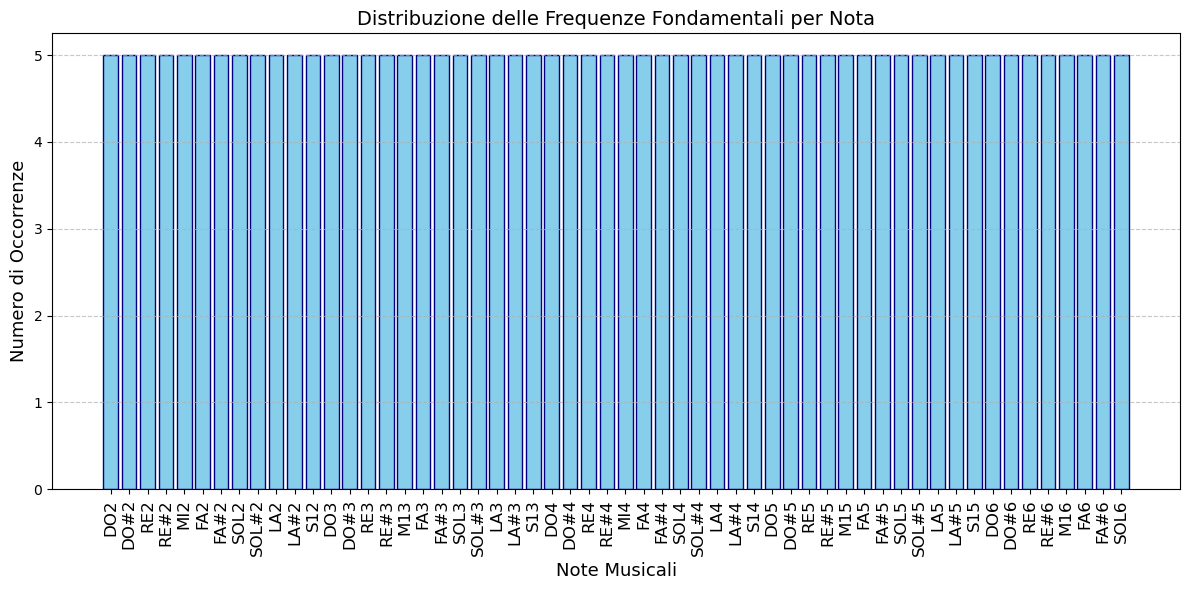

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

# 1. Caricamento dati (Assicurati che i file siano nella stessa cartella)
note_musicali = {}
with open('note_musicali.csv', 'r') as f:
    for line in f:
        note, freq = line.strip().split(',')
        note_musicali[note] = float(freq)

data = np.loadtxt('fundamentals.csv')
#i dati sono duplicati, prendo solo le prime 280 righe
data = data[:280]

# 2. Funzione per trovare la nota più vicina
def trova_nota_vicina(freq, dizionario_note):
    # Usiamo la differenza assoluta per trovare la nota con frequenza più simile
    note_nomi = list(dizionario_note.keys())
    note_freqs = np.array(list(dizionario_note.values()))
    
    # Calcola l'indice della nota più vicina
    indice_vicino = (np.abs(note_freqs - freq)).argmin()
    return note_nomi[indice_vicino]

note_rilevate = [trova_nota_vicina(f, note_musicali) for f in data]

conteggio = Counter(note_rilevate)

# ordino il grafico in base alla frequenza delle note musicali
note_ordinate = sorted(note_musicali.keys(), key=lambda x: note_musicali[x])
etichette = [n for n in note_ordinate if n in conteggio]
valori = [conteggio[n] for n in etichette]

plt.figure(figsize=(12, 6))
plt.bar(etichette, valori, color='skyblue', edgecolor='navy')
plt.xlabel('Note Musicali', fontsize=13)
plt.ylabel('Numero di Occorrenze', fontsize=13)
plt.title('Distribuzione delle Frequenze Fondamentali per Nota', fontsize=14)
plt.xticks(rotation=90, fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [3]:
# note del la2
index_la2 = np.where((data <= 157) & (data > 150))
print("La2 è presente nei file:", index_la2[0] + 1) 

La2 è presente nei file: [  9  62 161 190 204]


In [4]:
index = np.where(data <50)
print(index)

(array([], dtype=int64),)


In [5]:
np.max(data)

np.float64(1574.8081387851653)

In [6]:
np.min(data)

np.float64(65.37625643757816)